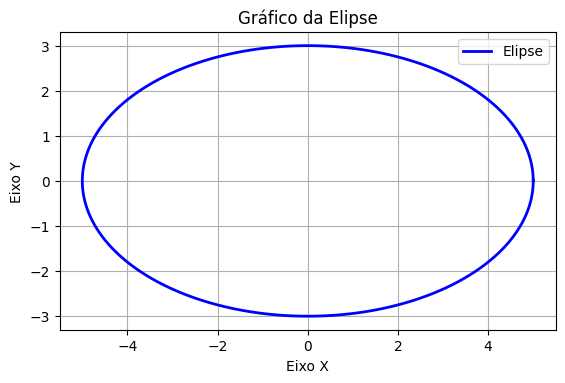

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def elipse(a,b):
    """
    Inicializa a seção elíptica.
    a: Semi-eixo maior (em x)
    b: Semi-eixo menor (em y)
    """
    if b >= a:
            raise ValueError("O semi-eixo 'a' (x) deve ser estritamente maior que 'b' (y).")
    
    # Parâmetros Focais da Elipse
    f = np.sqrt(a**2 - b**2) # Distãncia do Centro da Elipse até o Foco
    xi_0 = np.arccosh(a / f) # Coordenada radial elíptica \xi_0 que define a parede metálica externa da seção.
    
    # --- GERANDO OS PONTOS DA ELIPSE ---
    t = np.linspace(0, 2 * np.pi, 200) # Criamos um ângulo t que vai de 0 a 2*pi
    
    # Equação paramétrica da elipse
    x = a * np.cos(t)
    y = b * np.sin(t)
    
    # Retorna os pontos x e y para serem usados fora da função
    return x, y, f, xi_0


# Plota os dados da elipse (Validação)
fig, ax = plt.subplots()
x, y, f, xi_0 = elipse(5, 3) 

ax.plot(x, y, label='Elipse', color='blue', linestyle='-', linewidth=2)
ax.set_title("Gráfico da Elipse")
ax.set_xlabel("Eixo X")
ax.set_ylabel("Eixo Y")
ax.grid(True)
ax.legend()
ax.set_aspect('equal')
plt.show()


In [8]:
import scipy.special as sp

def equacao_raizes(f, xi_0, kc, m, tipo_modo):
    """Equação cujo zero determina o kc. Usa as funções de Mathieu."""

    q = (kc * f / 2)**2
    
    """
    mathieu_modcem1 -- A Função Par Modificada de Mathieu de Primeiro Tipo e Suas Derivadas.
    cem é usado para par
    sem é usado para impar
    """
    # sp.mathieu_modcem1 retorna: (valor_da_funcao, valor_da_derivada)
    ce_val, ce_der = sp.mathieu_modcem1(m, q, xi_0)
    
    # Aplicação das Condições de Contorno na Extremidade da Elipse
    if tipo_modo.upper() == 'TM':
        return ce_val  # TM exige que a função seja 0 na borda
    elif tipo_modo.upper() == 'TE':
        return ce_der  # TE exige que a derivada seja 0 na borda
    else:
        raise ValueError("Tipo deve ser 'TE' ou 'TM'")

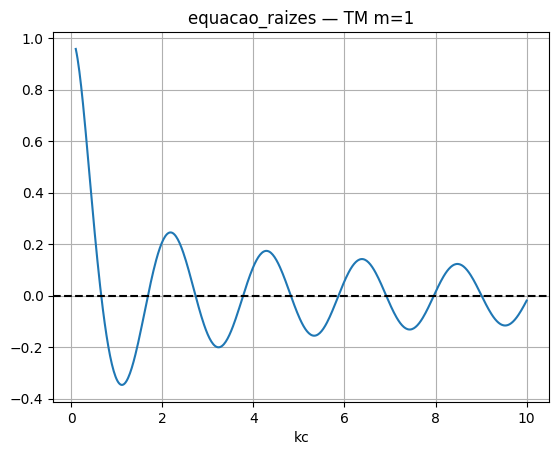

In [9]:
x, y, f, xi_0 = elipse(5, 3)

kc_vec = np.linspace(0.1, 10, 500)
vals = [equacao_raizes(f, xi_0, kc, m=0, tipo_modo='TM') for kc in kc_vec]

fig, ax = plt.subplots()
ax.plot(kc_vec, vals)
ax.axhline(0, color='k', linestyle='--')

ax.set_xlabel('kc')
ax.set_title('equacao_raizes — TM m=1')
ax.grid(True)
plt.show()

In [10]:
import scipy.optimize as opt

def k_c(a, b, m, n, tipo_modo):
    """Busca a n-ésima raiz da função de Mathieu para encontrar kc."""
    # 1. Primeiro, precisamos extrair os parâmetros geométricos da elipse
    _, _, f, xi_0 = elipse(a, b)
    
    # Chute inicial baseado em um círculo equivalente
    r_eq = (a + b) / 2.0
    if tipo_modo.upper() == 'TM':
        kc_guess = sp.jn_zeros(m, n)[n-1] / r_eq
    else:
        kc_guess = sp.jnp_zeros(m, n)[n-1] / r_eq
        
    # Criamos um vetor de busca para "enlaçar" a raiz corretamente
    kcs = np.linspace(kc_guess * 0.3, kc_guess * 2.5, 500) # Alarguei um pouco a margem por segurança
    
    # CORREÇÃO: Passando todos os parâmetros necessários para a equacao_raizes
    valores = [equacao_raizes(f, xi_0, k, m, tipo_modo) for k in kcs]
    
    # Detecta mudanças de sinal (onde a função cruza o zero)
    mudancas_sinal = np.where(np.diff(np.sign(valores)))[0]
    
    if len(mudancas_sinal) < n:
        raise RuntimeError(f"Não foi possível encontrar a {n}ª raiz. Tente expandir o intervalo de kcs.")
        
    # Seleciona o índice correspondente à n-ésima raiz desejada
    idx_raiz = mudancas_sinal[n-1]
    
    # Para o brentq funcionar perfeitamente, criamos uma função rápida (lambda) onde o 'k' varia:
    f_auxiliar = lambda k: equacao_raizes(f, xi_0, k, m, tipo_modo)
    
    # Refina a raiz encontrada usando o algoritmo de Brent
    kc_otimizado = opt.brentq(f_auxiliar, kcs[idx_raiz], kcs[idx_raiz+1])
    
    return kc_otimizado

In [12]:
# Exemplo: Encontrar o kc do modo fundamental TM (m=0, n=1) para a elipse (5,3)
raiz_kc = k_c(a=5, b=3, m=1, n=1, tipo_modo='TM')
print(f"O kc otimizado encontrado foi: {raiz_kc}")

O kc otimizado encontrado foi: 0.9154568529389722


In [13]:
# Teste de validação: Elipse quase circular (Raio ~ 3)
a_teste = 3.0
b_teste = 2.9999  # Não use exatamente igual para não dar divisão por zero no arccosh

# Calcula pelo seu código (Modo TM, m=0, n=1)
kc_elipse = k_c(a_teste, b_teste, m=0, n=1, tipo_modo='TM')

# Calcula a resposta teórica exata para o círculo usando scipy
import scipy.special as sp
raio = 3.0
kc_circulo_teorico = sp.jn_zeros(0, 1)[0] / raio

print(f"Abordagem Elíptica: {kc_elipse:.6f}")
print(f"Teórico do Círculo: {kc_circulo_teorico:.6f}")
print(f"Erro: {abs(kc_elipse - kc_circulo_teorico):.2e}")

Abordagem Elíptica: 0.801622
Teórico do Círculo: 0.801609
Erro: 1.34e-05


In [2]:
"""
Ferramenta NV-Maser - Cálculo Estático e Exato de Cavidades Elípticas
Otimização automatizada do comprimento L para degenerescência TE111/TM010
utilizando funções de Mathieu.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches
import scipy.constants as sc
import scipy.special as sp
import scipy.optimize as opt

# ── Constantes ─────────────────────────────────────────────────
TARGET = 2.87  # GHz (Frequência alvo NV Center)
C0 = sc.c
X01 = sp.jn_zeros(0, 1)[0]
XP11 = sp.jnp_zeros(1, 1)[0]

# ── Motor Físico Exato (Mathieu) ───────────────────────────────
class SecaoEliptica2D:
    def __init__(self, a_mm, b_mm, er=1.0):
        # Conversão para metros internamente
        self.a = a_mm * 1e-3
        self.b = b_mm * 1e-3
        self.er = er
        self.c_m = C0 / np.sqrt(er)
        
        if self.b >= self.a:
            self.a, self.b = self.b, self.a + 1e-6 # Evita quebra se e=0
            
        self.f = np.sqrt(self.a**2 - self.b**2)
        self.xi_0 = np.arccosh(self.a / self.f)
        
    def _equacao_raizes(self, kc, m, tipo_modo):
        q = (kc * self.f / 2)**2
        ce_val, ce_der = sp.mathieu_modcem1(m, q, self.xi_0)
        if tipo_modo.upper() == 'TM':
            return ce_val
        elif tipo_modo.upper() == 'TE':
            return ce_der
        else:
            raise ValueError("Tipo deve ser 'TE' ou 'TM'")

    def k_c(self, m, n, tipo_modo):
        r_eq = (self.a + self.b) / 2.0
        kc_guess = sp.jn_zeros(m, n)[n-1] / r_eq if tipo_modo == 'TM' else sp.jnp_zeros(m, n)[n-1] / r_eq
        
        kcs = np.linspace(kc_guess * 0.5, kc_guess * 2.0, 500)
        valores = [self._equacao_raizes(k, m, tipo_modo) for k in kcs]
        mudancas_sinal = np.where(np.diff(np.sign(valores)))[0]
        
        if len(mudancas_sinal) < n:
            return kc_guess 
            
        idx_raiz = mudancas_sinal[n-1]
        try:
            kc_otimizado = opt.brentq(self._equacao_raizes, kcs[idx_raiz], kcs[idx_raiz+1], args=(m, tipo_modo))
            return kc_otimizado
        except ValueError:
            return kc_guess

# ── Funções de Cálculo ─────────────────────────────────────────
def fTM_exact(a, e, er):
    b = a * np.sqrt(1 - e**2)
    cav = SecaoEliptica2D(a, b, er)
    kc = cav.k_c(0, 1, 'TM')
    return (cav.c_m / (2 * np.pi)) * kc / 1e9

def fTE_exact(a, e, L, er):
    b = a * np.sqrt(1 - e**2)
    cav = SecaoEliptica2D(a, b, er)
    kc = cav.k_c(1, 1, 'TE')
    fc = (cav.c_m / (2 * np.pi)) * kc
    fz = C0 / (2 * (L * 1e-3) * np.sqrt(er))
    return np.sqrt(fc**2 + fz**2) / 1e9

def Ldegen_bisect_exact(a, e, er, Lo=10.0, Hi=500.0, tol=1e-6):
    """Encontra o comprimento ótimo L onde TE111 e TM010 degeneram."""
    ftm = fTM_exact(a, e, er)
    if fTE_exact(a, e, Lo, er) <= ftm: return None
    if fTE_exact(a, e, Hi, er) >= ftm: return None
    
    for _ in range(100):
        mid = (Lo + Hi) / 2
        if fTE_exact(a, e, mid, er) > ftm:
            Lo = mid
        else:
            Hi = mid
        if Hi - Lo < tol:
            break
    Lc = (Lo + Hi) / 2
    return {'L': Lc, 'f': fTE_exact(a, e, Lc, er)}

def mode_volume(a, e, L):
    return np.pi * a * a * np.sqrt(1 - e**2) * L

# ── Aproximações de Campo (para renderização espacial) ─────────
def Reff(a, e): return a * np.power(1 - e**2, 0.25)
def _safe_r(X, Y): return np.where(X**2 + Y**2 < 1e-18, 1e-9, np.sqrt(X**2 + Y**2))
def ellipse_mask(X, Y, a, e):
    b = a * np.sqrt(1 - e**2)
    return X**2 / a**2 + Y**2 / b**2 <= 1.0

def F_Eperp(X, Y, a, e, phi0):
    kc = XP11 / Reff(a, e)
    r = _safe_r(X, Y)
    ph = np.arctan2(Y, X) - phi0
    kr = kc * r
    Er = sp.jvp(1, kr, 1) * np.cos(ph)
    Ephi = sp.jv(1, kr) / kr * np.sin(ph)
    return np.sqrt(Er**2 + Ephi**2)

def F_Hz(X, Y, a, e, phi0):
    kc = XP11 / Reff(a, e)
    r = _safe_r(X, Y)
    return sp.jv(1, kc * r) * np.cos(np.arctan2(Y, X) - phi0)

def F_Hperp(X, Y, a, e, phi0):
    kc = XP11 / Reff(a, e)
    r = _safe_r(X, Y)
    phi = np.arctan2(Y, X)
    dp = phi - phi0
    kr = kc * r
    dj = sp.jvp(1, kr, 1)
    j1r = sp.jv(1, kr) / r
    gx = kc * dj * np.cos(dp) * np.cos(phi) + j1r * np.sin(dp) * np.sin(phi)
    gy = kc * dj * np.cos(dp) * np.sin(phi) - j1r * np.sin(dp) * np.cos(phi)
    return np.sqrt(gx**2 + gy**2)

def F_Ez(X, Y, a, e, _=None):
    return np.maximum(0, sp.jv(0, X01 / Reff(a, e) * _safe_r(X, Y)))

def F_Hphi(X, Y, a, e, _=None):
    return np.maximum(0, sp.jv(1, X01 / Reff(a, e) * _safe_r(X, Y)))

# ── Funções de Desenho (Painéis) ───────────────────────────────
def _overlay(ax, a, e):
    b = a * np.sqrt(1 - e**2)
    foc = a * e
    th = np.linspace(0, 2 * np.pi, 400)
    ax.plot(a * np.cos(th), b * np.sin(th), 'w-', lw=1, alpha=0.6)
    ax.plot([foc, -foc], [0, 0], 'o', color='#FF6B35', ms=5, zorder=5, label='Focos')
    ax.plot(0, 0, '+', color='#7FBA00', ms=9, mew=2, zorder=5, label='Centro')

def draw_field(ax, Ffn, a, e, phi0, title, cmap='inferno', signed=False, N=150):
    b = a * np.sqrt(1 - e**2)
    x = np.linspace(-a * 1.05, a * 1.05, N)
    y = np.linspace(-b * 1.05, b * 1.05, N)
    X, Y = np.meshgrid(x, y)
    F = np.where(ellipse_mask(X, Y, a, e), Ffn(X, Y, a, e, phi0), np.nan)
    vm = np.nanmax(np.abs(F)) or 1.0
    kw = dict(extent=[-a*1.05, a*1.05, -b*1.05, b*1.05], origin='lower', aspect='equal', cmap=cmap, interpolation='bilinear')
    ax.imshow(F, vmin=-vm if signed else 0, vmax=vm, **kw)
    _overlay(ax, a, e)
    ax.set_title(title, fontsize=8, pad=2)
    ax.set_xlabel('x (mm)', fontsize=7)
    ax.set_ylabel('y (mm)', fontsize=7)
    ax.tick_params(labelsize=6)

def draw_s11(ax, fte, ftm):
    flo = min(fte, ftm, TARGET) * 0.87
    fhi = max(fte, ftm, TARGET) * 1.13
    f = np.linspace(flo, fhi, 2000)
    DEPTH = -35

    def S11_dip(fc, Q):
        d = 2 * Q * (f - fc) / fc
        return DEPTH / (1 + d**2)

    ax.axhline(0, color='grey', lw=0.8, alpha=0.5)
    ax.plot(f, S11_dip(fte, 9000), color='#1F77B4', lw=2, label=f'TE₁₁₁  {fte:.4f} GHz')
    ax.plot(f, S11_dip(ftm, 7000), color='#D62728', lw=2, label=f'TM₀₁₀  {ftm:.4f} GHz')
    ax.axvline(TARGET, color='#2CA02C', ls='--', lw=1.5, label=f'{TARGET} GHz')

    df = abs(fte - ftm) * 1000
    ax.annotate(f'|Δf| = {df:.3f} MHz', xy=(0.98, 0.08), xycoords='axes fraction',
                ha='right', va='bottom', fontsize=8, color='purple',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='purple', alpha=0.85))

    ax.set_ylim(DEPTH * 1.15, 5)
    ax.set_ylabel('S₁₁ (dB)', fontsize=8)
    ax.set_xlabel('Frequência (GHz)', fontsize=8)
    ax.set_title('S₁₁ vs Frequência (Exato - Mathieu)', fontsize=9)
    ax.legend(fontsize=7, loc='lower center')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

def draw_Lscan(ax, a, e, er, Lcur):
    LSTART = 10.0
    Lmax = max(100.0, Lcur * 1.5)
    Ls = np.linspace(LSTART, Lmax, 100)
    
    fTEs = [fTE_exact(a, e, l_val, er) for l_val in Ls]
    ftmC = fTM_exact(a, e, er)
    fLcur = fTE_exact(a, e, Lcur, er)
    
    ylo = min(1.0, ftmC - 0.2)
    yhi = max(5.0, ftmC + 0.2)

    ax.plot(Ls, fTEs, color='#1F77B4', lw=2, label='TE₁₁₁')
    ax.axhline(ftmC, color='#D62728', lw=2, label=f'TM₀₁₀ = {ftmC:.4f} GHz')
    ax.axhline(TARGET, color='#2CA02C', ls='--', lw=1.5, label=f'{TARGET} GHz Alvo')

    ax.plot([LSTART, Lcur], [fLcur, fLcur], color='#27AE60', lw=0.8, ls=':', alpha=0.7)
    ax.plot([Lcur, Lcur], [ylo, fLcur], color='#27AE60', lw=0.8, ls=':', alpha=0.7)
    ax.plot(Lcur, fLcur, 'o', color='#27AE60', ms=14, zorder=8, alpha=0.3)
    ax.plot(Lcur, fLcur, 'o', color='#27AE60', ms=9, zorder=9, label=f'L_degen = {Lcur:.4f} mm')
    ax.plot(Lcur, fLcur, 'o', color='white', ms=4, zorder=10)
    
    ax.annotate(f' ✓ L_degen = {Lcur:.4f} mm\n    f = {fLcur:.4f} GHz',
                xy=(Lcur, fLcur), xytext=(min(Lcur + (Lmax - LSTART) * 0.07, Lmax * 0.78), fLcur + (yhi - ylo) * 0.12),
                fontsize=9, color='#145A32', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', fc='#EAFAF1', ec='#27AE60', lw=1.5),
                arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.8))
    
    ax.set_xlim(LSTART, Lmax)
    ax.set_ylim(ylo, yhi)
    ax.set_xlabel('Altura da Cavidade L (mm)', fontsize=9)
    ax.set_ylabel('f (GHz)', fontsize=9)
    ax.set_title('Cruzamento Analítico (Mathieu)', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=8)

# ── Construtor da Figura Master ────────────────────────────────
def build_figure(a, e, L, er, phi0, N=150):
    fte = fTE_exact(a, e, L, er)
    ftm = fTM_exact(a, e, er)
    df = abs(fte - ftm) * 1000
    onT = abs(ftm - TARGET) / TARGET < 0.015
    degen = df < 20

    if degen and onT:
        st, sc = f'✓ DEGENERADO @ 2.87 GHz   |Δf| = {df:.3f} MHz', 'green'
    elif degen:
        st, sc = f'~ Degenerado mas fora do alvo   f(TM) = {ftm:.4f} GHz', 'orange'
    else:
        st, sc = f'✗ Não degenerado   |Δf| = {df:.3f} MHz', 'red'

    b = a * np.sqrt(1 - e**2)
    fig = plt.figure(figsize=(18, 11))
    fig.suptitle(f'Maser Exato (Mathieu): a={a:.2f} mm | b={b:.2f} mm | L={L:.4f} mm | e={e:.3f} | ε_r={er:.2f}\n'
                 f'f(TE)={fte:.4f} GHz | f(TM)={ftm:.4f} GHz\n{st}',
                 fontsize=11, fontweight='bold', color=sc)

    gs = GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

    # Linha 1 (TE)
    draw_field(fig.add_subplot(gs[0, 0]), F_Eperp, a, e, phi0, '|E_⊥| TE₁₁', N=N)
    draw_field(fig.add_subplot(gs[0, 1]), F_Hz, a, e, phi0, 'H_z TE₁₁', cmap='RdBu_r', signed=True, N=N)
    draw_field(fig.add_subplot(gs[0, 2]), F_Hperp, a, e, phi0, '|H_⊥| TE₁₁', N=N)

    # Linha 2 (TM + S11)
    draw_field(fig.add_subplot(gs[1, 0]), F_Ez, a, e, phi0, 'E_z TM₀₁', N=N)
    draw_field(fig.add_subplot(gs[1, 1]), F_Hphi, a, e, phi0, '|H_φ| TM₀₁', N=N)
    draw_s11(fig.add_subplot(gs[1, 2]), fte, ftm)

    # Linha 3 (L-scan)
    draw_Lscan(fig.add_subplot(gs[2, :]), a, e, er, L)

    return fig

def print_summary(a, e, L, er):
    b = a * np.sqrt(1 - e**2)
    foc = a * e
    fte = fTE_exact(a, e, L, er)
    ftm = fTM_exact(a, e, er)
    df = abs(fte - ftm) * 1000
    vm = mode_volume(a, e, L)
    
    print('=' * 65)
    print('   CAVIDADE ELÍPTICA NV-MASER — RESULTADOS EXATOS (MATHIEU)')
    print('=' * 65)
    print(f'   a (semi-eixo maior)      = {a:.4f} mm')
    print(f'   b (semi-eixo menor)      = {b:.4f} mm')
    print(f'   e (excentricidade)       = {e:.4f}')
    print(f'   c (distância focal)      = {foc:.4f} mm')
    print(f'   ε_r (permissividade)     = {er:.2f}')
    print('-' * 65)
    print(f'   f(TM010)                 = {ftm:.6f} GHz')
    print(f'   L_degen (calculado)      = {L:.6f} mm')
    print(f'   f(TE111) @ L_degen       = {fte:.6f} GHz')
    print(f'   |Δf| (erro precisão)     = {df:.6f} MHz')
    print(f'   Volume do modo           = {vm/1e3:.4f} cm³')
    print('=' * 65)

# ── Execução ───────────────────────────────────────────────────
if __name__ == '__main__':
    # 1. Defina os parâmetros estruturais
    a_val = 14.2
    e_val = 0.54
    er_val = 9.4
    phi0_val = 0.0

    print("Calculando raízes exatas de Mathieu... Aguarde.")
    
    # 2. O algoritmo busca o L ideal automaticamente
    resultado = Ldegen_bisect_exact(a_val, e_val, er_val)
    
    if resultado:
        L_otimizado = resultado['L']
        
        # 3. Imprime os valores rigorosos no console
        print_summary(a_val, e_val, L_otimizado, er_val)
        
        # 4. Gera e exibe a figura gráfica
        fig = build_figure(a_val, e_val, L_otimizado, er_val, phi0_val)
        plt.show()
    else:
        print("Erro: Não foi possível encontrar um ponto de degenerescência TE/TM para estes parâmetros.")

Calculando raízes exatas de Mathieu... Aguarde.
   CAVIDADE ELÍPTICA NV-MASER — RESULTADOS EXATOS (MATHIEU)
   a (semi-eixo maior)      = 14.2000 mm
   b (semi-eixo menor)      = 11.9516 mm
   e (excentricidade)       = 0.5400
   c (distância focal)      = 7.6680 mm
   ε_r (permissividade)     = 9.40
-----------------------------------------------------------------
   f(TM010)                 = 2.892927 GHz
   L_degen (calculado)      = 23.726202 mm
   f(TE111) @ L_degen       = 2.892927 GHz
   |Δf| (erro precisão)     = 0.000014 MHz
   Volume do modo           = 12.6501 cm³


C:\Users\filip\AppData\Local\Temp\ipykernel_17196\2963333797.py:310: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
